# 02 - Baseline Model: Random Forest
Predicting ECD fragment ion intensity using a Random Forest regressor.
Target variable is log-transformed intensity (`log1p`) due to the heavily skewed distribution.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from src.metrics import pearson_correlation
from src.metrics import spectral_angle

/home/oogy/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load & Parse Data
Rebuild the long-format `ion_df` from the raw parquet (same logic as EDA notebook).

In [4]:
df = pd.read_parquet("data_for_student.parquet")
print(f"Loaded {len(df):,} spectra")

Loaded 379,534 spectra


In [5]:
# Explode matched_ions and intensity into long format
ion_df = df[['modified_sequence', 'matched_ions', 'intensity']].copy()
ion_df = ion_df.explode(['matched_ions', 'intensity']).reset_index(drop=True)
ion_df.columns = ['sequence', 'ion', 'intensity']

# Drop rows from spectra with empty matched_ions lists (explode turns these into NaN)
n_before = len(ion_df)
ion_df = ion_df.dropna(subset=['ion', 'intensity'])
print(f"Dropped {n_before - len(ion_df):,} NaN rows from empty-ion spectra")

ion_df['intensity'] = ion_df['intensity'].astype(float)

# Parse ion string into type, fragment number, charge
ion_df['ion_charge'] = ion_df['ion'].str.extract(r'\^(\d+)').fillna(1).astype(int)
ion_df['ion_type']   = ion_df['ion'].str[0]

fn = ion_df['ion'].str.extract(r'[A-Za-z]+(\d+)')[0]
n_unparsed = fn.isna().sum()
if n_unparsed:
    print(f"Dropping {n_unparsed:,} ions with unparseable fragment number")
    ion_df = ion_df[fn.notna()].copy()
    fn = fn[fn.notna()]
ion_df['fragment_number'] = fn.astype(int)

# Encode ion type — include both 'c' and 'C' since ECD notation varies by tool
ion_type_map = {'c': 0, 'C': 0, 'z': 1, 'Z': 2}
ion_df['ion_type_encoded'] = ion_df['ion_type'].map(ion_type_map)
assert ion_df['ion_type_encoded'].notna().all(), (
    f"Unknown ion types found:\n{ion_df[ion_df['ion_type_encoded'].isna()]['ion_type'].value_counts()}"
)

# Peptide length on clean sequence (strip modification tags like [UNIMOD:35])
ion_df['clean_sequence'] = ion_df['sequence'].str.replace(r'\[.*?\]', '', regex=True)
ion_df['pep_length'] = ion_df['clean_sequence'].str.len()
ion_df['relative_position'] = ion_df['fragment_number'] / ion_df['pep_length']

print(f"Total ions: {len(ion_df):,}")
ion_df.head(3)

Dropped 5 NaN rows from empty-ion spectra
Total ions: 9,035,296


,sequence,ion,intensity,ion_charge,ion_type,fragment_number,ion_type_encoded,clean_sequence,pep_length,relative_position
0,EENRRPPSGDNAREKPPSSGVKK,C4,4693.457031,1,C,4,0,EENRRPPSGDNAREKPPSSGVKK,23,0.173913
1,EENRRPPSGDNAREKPPSSGVKK,z4,2065.627441,1,z,4,1,EENRRPPSGDNAREKPPSSGVKK,23,0.173913
2,EENRRPPSGDNAREKPPSSGVKK,z5,3287.163574,1,z,5,1,EENRRPPSGDNAREKPPSSGVKK,23,0.217391


## 2. Feature Engineering: Amino Acid Composition
Count occurrences of each of the 20 standard amino acids in the peptide sequence.
Modifications like `[UNIMOD:35]` are stripped before counting.
CHANGE: swapped global amino acid count for local window (= 4 residues around cleave site, more relevant for intensity)

In [8]:
AA_INDEX = {aa: idx for idx, aa in enumerate('ACDEFGHIKLMNPQRSTVWY')}

clean_seq = ion_df['sequence'].str.replace(r'\[.*?\]', '', regex=True)
i = ion_df['fragment_number'].values
n = clean_seq.str.len().values
clean_arr = clean_seq.values

def get_residue_vec(clean_arr, pos_arr, length_arr):
    result = np.full(len(clean_arr), -1, dtype=int)
    for j, (seq, p, l) in enumerate(zip(clean_arr, pos_arr, length_arr)):
        if 0 <= p < l:
            result[j] = AA_INDEX.get(seq[p], -1)
    return result

ion_df['res_m2'] = get_residue_vec(clean_arr, i-2, n)
ion_df['res_m1'] = get_residue_vec(clean_arr, i-1, n)
ion_df['res_0']  = get_residue_vec(clean_arr, i,   n)
ion_df['res_p1'] = get_residue_vec(clean_arr, i+1, n)

## 3. Prepare Features and Target

In [9]:
FEATURE_COLS = [
    'ion_type_encoded',
    'fragment_number',
    'ion_charge',
    'pep_length',
    'relative_position',
    'res_m2', 'res_m1', 'res_0', 'res_p1'
]

X = ion_df[FEATURE_COLS].values
y = np.log1p(ion_df['intensity'].values)

print(f"Feature matrix shape: {X.shape}")
print(f"Target range (log scale): {y.min():.2f} – {y.max():.2f}")## 3. Prepare Features and Target

Feature matrix shape: (9035296, 9)
Target range (log scale): 6.78 – 18.51


## 3.5 Set dataframe to 20% of dataset -> faster training for testing changes

In [12]:
ion_df = ion_df.sample(frac=0.2, random_state=42) 

## 4. Train / Test Split
80/20 split. Stratification is not used here (continuous target).

In [14]:
# Split at peptide level to prevent the same sequence appearing in both train and test
# .tolist() converts from PyArrow-backed array to plain Python list that sklearn can index
y = np.log1p(ion_df['intensity'].values)
unique_seqs = ion_df['sequence'].unique().tolist()
train_seqs, test_seqs = train_test_split(unique_seqs, test_size=0.2, random_state=42)
train_seqs, test_seqs = set(train_seqs), set(test_seqs)

train_mask = ion_df['sequence'].isin(train_seqs)
mask = train_mask.to_numpy()

X_train = ion_df.loc[train_mask,  FEATURE_COLS].values
X_test  = ion_df.loc[~train_mask, FEATURE_COLS].values
y_train = y[mask]
y_test  = y[~mask]

print(f"Train: {X_train.shape[0]:,} samples ({len(train_seqs):,} peptides)")
print(f"Test:  {X_test.shape[0]:,} samples ({len(test_seqs):,} peptides)")

Train: 1,448,187 samples (244,570 peptides)
Test:  358,872 samples (61,143 peptides)


## 5. Train Random Forest
`n_jobs=-1` uses all CPU cores. `n_estimators=100` is a solid default for a baseline.
Training on ~7M samples will take a few minutes.

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,       # cap depth to keep training time manageable
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   55.0s


Training complete.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.2min finished


In [16]:
import joblib
joblib.dump(rf, 'rf.baseline.joblib')
print("Model saved.")

Model saved.


## 6. Evaluate

In [17]:
y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE (log scale):  {mae:.4f}")
print(f"R²  (log scale):  {r2:.4f}")

# Also report MAE on original intensity scale for interpretability
mae_orig = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(f"MAE (raw scale):  {mae_orig:,.0f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s


MAE (log scale):  0.9857
R²  (log scale):  0.1045
MAE (raw scale):  37,154


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


## 7. Predicted vs Actual Plot

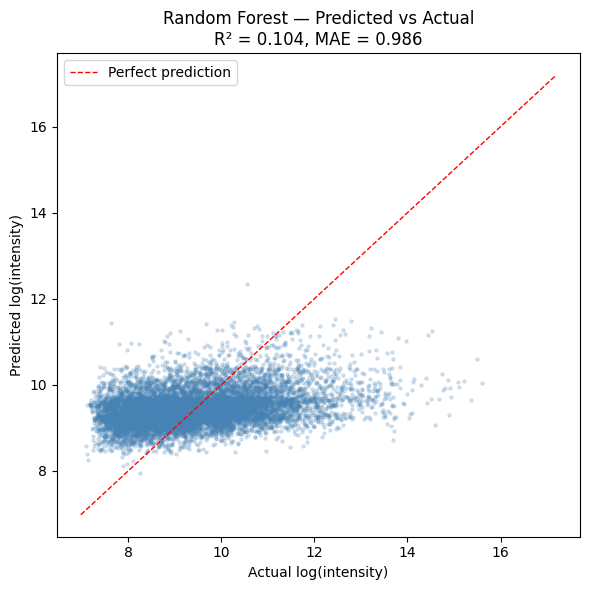

In [18]:
# Subsample for plotting (plotting 1.8M points is slow)
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), size=10_000, replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test[idx], y_pred[idx], alpha=0.2, s=5, color='steelblue')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')

ax.set_xlabel('Actual log(intensity)')
ax.set_ylabel('Predicted log(intensity)')
ax.set_title(f'Random Forest — Predicted vs Actual\nR² = {r2:.3f}, MAE = {mae:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

## 8. Feature Importance

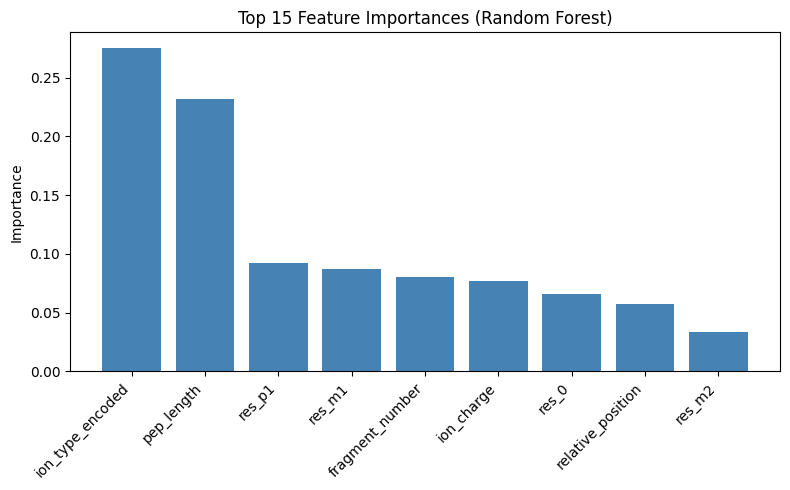

In [22]:
importances = rf.feature_importances_
feat_names  = FEATURE_COLS

sorted_idx = np.argsort(importances)[::-1]
top_n = 9

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    range(top_n),
    importances[sorted_idx[:top_n]],
    color='steelblue'
)
ax.set_xticks(range(top_n))
ax.set_xticklabels(
    [feat_names[i] for i in sorted_idx[:top_n]],
    rotation=45, ha='right'
)
ax.set_ylabel('Importance')
ax.set_title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [20]:
print(f"{'Metric':<25} {'Value':>15}")
print("-" * 41)
print(f"{'MAE (log scale)':<25} {mae:>15.4f}")
print(f"{'R² (log scale)':<25} {r2:>15.4f}")
print(f"{'MAE (raw scale)':<25} {mae_orig:>15,.0f}")

Metric                              Value
-----------------------------------------
MAE (log scale)                    0.9857
R² (log scale)                     0.1045
MAE (raw scale)                    37,154


## 9 Spectral Angle 
malte -> spectral angle versuch über iteration über alle sequenzen und averagen

In [21]:
#Daten erstmal einziehen
results=ion_df.loc[~train_mask].copy()
results["actual"] = np.expm1(y_test)
results["predicted"] = np.expm1(y_pred)

grouped_data = results.groupby("sequence") # grouping as we compare the relationship and not the single frags
sa_score=[]
pearson_score=[]
for seqence, peptide_rows in grouped_data:
    # get data
    true_vector = peptide_rows["actual"].values 
    predicted_vector = peptide_rows["predicted"].values

    #add the spectral angle
    sa_score.append(spectral_angle(true_vector, predicted_vector))
    if np.std(true_vector) == 0 or np.std(predicted_vector) == 0:
        pearson_score.append(0.0)  # default needed for 0  otherwise failure
    else:
        pearson_score.append(pearson_correlation(true_vector, predicted_vector))

print(f"Mean spectral Angle: {np.mean(sa_score)}")
print(f"Mean Pearson Correlation: {np.mean(pearson_score)}")

Mean spectral Angle: 0.7591957452625856
Mean Pearson Correlation: 0.3957642889081801


## 10. Summary

See cell output above for metrics.

**Features used:** ion type, fragment number, charge, peptide length, relative position, local cleavage site window.
